# This notebook makes tables and figures

## Imports, configuration, and functions

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib as mpl
font = {'family' : 'Arial',
        'size'   : 9}
plt.rc('font', **font)
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rc('hatch', color='w', linewidth=0.5)
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
import colorcet as cc

cmap = mpl.colors.LinearSegmentedColormap.from_list('cet_cbl2', cc.CET_CBL2[::-1])
cmap_cw = mpl.colors.LinearSegmentedColormap.from_list('cet_cbtd1', cc.CET_CBTD1)

In [2]:
def light_color(color, alpha=0.5):
    if isinstance(color, str):
        color = mpl.colors.to_rgb(color)
    return tuple([c + (1 - c) * (1 - alpha) for c in color])
    

def highlight_col(col, highlight_type='max', scientific_notation=False, involve_second=True):
    if np.mean(col)>0.01:
        col = np.round(col.values, 3)
    else:
        col = col.values
    
    if highlight_type == 'none':
        sorted_col = np.zeros_like(col)*np.nan
    elif highlight_type == 'max':
        sorted_col = np.sort(col[~np.isnan(col)])[::-1]
    elif highlight_type == 'min':
        sorted_col = np.sort(col[~np.isnan(col)])
    else:
        raise ValueError("highlight_type must be 'none' 'max' or 'min'.")
    is_extreme = col==sorted_col[0]
    is_second_extreme = col==sorted_col[1]
    
    styled_col = []
    if scientific_notation and np.mean(col)<=0.01:
        for i, v in enumerate(col):
            if is_extreme[i]:
                styled_col.append(f'\\textbf{{\\underline{{{v:.3E}}}}}'.replace('E-0','E-'))
            elif is_second_extreme[i] and involve_second:
                styled_col.append(f'\\textbf{{{v:.3E}}}'.replace('E-0','E-'))
            else:
                styled_col.append(f'{v:.3E}'.replace('E-0','E-'))
    else:
        for i, v in enumerate(col):
            if is_extreme[i]:
                styled_col.append(f'\\textbf{{\\underline{{{v:.3f}}}}}')
            elif is_second_extreme[i] and involve_second:
                styled_col.append(f'\\textbf{{{v:.3f}}}')
            else:
                styled_col.append(f'{v:.3f}')
    return styled_col


def highlight(df, max_cols=[], min_cols=[], scientific_notation=False, involve_second=True):
    if len(max_cols)==0 and len(min_cols)==0:
        for col in df.columns:
            df[col] = highlight_col(df[col], 'none', scientific_notation, involve_second)
    else:
        for col in max_cols:
            highlighted = highlight_col(df[col], 'max', scientific_notation, involve_second)
            df[col] = highlighted
            # Add arrow to column heading for max
            if not df.columns[df.columns.get_loc(col)].endswith(' (↑)'):
                df = df.rename(columns={col: f"{col} (↑)"})
        for col in min_cols:
            highlighted = highlight_col(df[col], 'min', scientific_notation, involve_second)
            df[col] = highlighted
            # Add arrow to column heading for min
            if not df.columns[df.columns.get_loc(col)].endswith(' (↓)'):
                df = df.rename(columns={col: f"{col} (↓)"})
    return df

def to_grayscale(fig):
    fig.canvas.draw()
    img = np.array(fig.canvas.renderer.buffer_rgba())
    grayscale_img = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])
    fig_gray, ax_gray = plt.subplots(figsize=(fig.get_size_inches()), dpi=fig.dpi)
    ax_gray.imshow(grayscale_img, cmap=plt.get_cmap('gray'), vmin=0, vmax=255)
    ax_gray.axis('off')  # Turn off the axis
    ax_gray.set_title('Grayscale plot')

## Illustration of the modification function

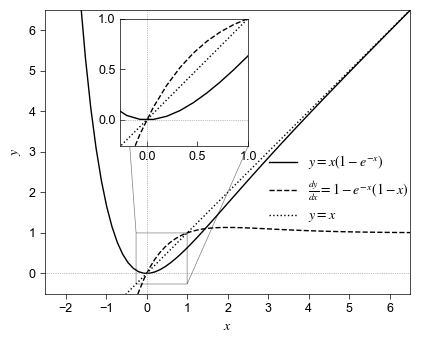

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5), tight_layout=True)
sub_ax = ax.inset_axes([0.156, 0.52, 0.45, 0.45])
# indicate the inset
ax.indicate_inset_zoom(sub_ax, edgecolor='black', lw=0.5,)
# make axis ticks inner for sub_ax
sub_ax.tick_params(direction='in', which='both')

ax.set_xlabel(r'$x$', fontsize=10)
ax.set_ylabel(r'$y$', fontsize=10)

x = np.linspace(-6.5, 6.5, 100)
y = x * (1-np.exp(-x))
yprime = 1 - np.exp(-x)*(1-x)

ax.plot(x, y, color='black', lw=1., label=r'$y = x(1 - e^{-x})$')
ax.plot(x, yprime, color='black', lw=1., ls='--', label=r"$\frac{dy}{dx} = 1 - e^{-x}(1-x)$")
ax.plot(x, x, color='black', lw=1., ls=':', label=r'$y = x$')

sub_ax.plot(x, y, color='black', lw=1.)
sub_ax.plot(x, yprime, color='black', lw=1., ls='--')
sub_ax.plot(x, x, color='black', lw=1., ls=':')
ax.axhline(0, color='grey', lw=0.5, ls=':')
ax.axvline(0, color='grey', lw=0.5, ls=':')
sub_ax.axhline(0, color='grey', lw=0.5, ls=':')
sub_ax.axvline(0, color='grey', lw=0.5, ls=':')

ax.set_aspect('equal')
ax.set_xlim(-2.5, 6.5)
ax.set_ylim(-0.5, 6.5)
sub_ax.set_aspect('equal')
sub_ax.set_xlim(-0.26, 1)
sub_ax.set_ylim(-0.26, 1)

ax.legend(loc='lower right', fontsize=10, frameon=False, bbox_to_anchor=(1.03, 0.2))

In [99]:
fig.savefig('modificaiton_function.pdf', bbox_inches='tight', dpi=600)

## Set up datasets

In [3]:
# InsectWingbeat and PenDigits are too large to efficiently compute, and thus are excluded

human_activity_datasets = ['BasicMotions', 'Cricket', 'Epilepsy', 'ERing', 'Handwriting', 'Libras', 'NATOPS', 'RacketSports', 'UWaveGestureLibrary']
motion_datasets = ['ArticularyWordRecognition', 'CharacterTrajectories', 'EigenWorms']
ecg_datasets = ['AtrialFibrillation', 'StandWalkJump']
eeg_meg_datasets = ['FingerMovements', 'MotorImagery', 'SelfRegulationSCP1', 'SelfRegulationSCP2', 'FaceDetection', 'HandMovementDirection']
audio_spectra_datasets = ['DuckDuckGeese', 'Heartbeat', 'PhonemeSpectra', 'SpokenArabicDigits', 'JapaneseVowels']
other_spatial_datasets = ['PEMS-SF', 'LSST']
other_nonspatial_datasets = ['EthanolConcentration']

spatial_datasets = human_activity_datasets + motion_datasets+other_spatial_datasets
non_spatial_datasets = ecg_datasets + eeg_meg_datasets + audio_spectra_datasets + other_nonspatial_datasets
print(f'There are {len(spatial_datasets)} spatial datasets and {len(non_spatial_datasets)} non-spatial datasets.')

rename_dict = {
    'original': 'No pretraining',
    'ts2vec': 'TS2Vec',
    'topo-ts2vec': 'Topo-TS2Vec (dynamic weights)',
    'topo-ts2vec-baseline': 'Topo-TS2Vec (fixed weights of 0.5)',
    'ggeo-ts2vec': 'GGeo-TS2Vec (dynamic weights)',
    'ggeo-ts2vec-baseline': 'GGeo-TS2Vec (fixed weights of 0.5)',
    'softclt': 'SoftCLT',
    'topo-softclt': 'Topo-SoftCLT (dynamic weights)',
    'topo-softclt-baseline': 'Topo-SoftCLT (fixed weights of 0.5)',
    'ggeo-softclt': 'GGeo-SoftCLT (dynamic weights)',
    'ggeo-softclt-baseline': 'GGeo-SoftCLT (fixed weights of 0.5)',
}

full_model_types = ['TS2Vec', 
                   'Topo-TS2Vec (fixed weights of 0.5)',
                   'Topo-TS2Vec (dynamic weights)', 
                   'GGeo-TS2Vec (fixed weights of 0.5)',
                   'GGeo-TS2Vec (dynamic weights)',
                   'SoftCLT',
                   'Topo-SoftCLT (fixed weights of 0.5)',
                   'Topo-SoftCLT (dynamic weights)',
                   'GGeo-SoftCLT (fixed weights of 0.5)',
                   'GGeo-SoftCLT (dynamic weights)']

model_types = ['TS2Vec', 'Topo-TS2Vec', 'GGeo-TS2Vec', 'SoftCLT', 'Topo-SoftCLT', 'GGeo-SoftCLT']

full_nobase_model_types = ['Topo-TS2Vec (fixed weights of 0.5)',
               'Topo-TS2Vec (dynamic weights)', 
               'GGeo-TS2Vec (fixed weights of 0.5)',
               'GGeo-TS2Vec (dynamic weights)', 
               'Topo-SoftCLT (fixed weights of 0.5)',
               'Topo-SoftCLT (dynamic weights)',
               'GGeo-SoftCLT (fixed weights of 0.5)', 
               'GGeo-SoftCLT (dynamic weights)']

nobase_model_types = ['Topo-TS2Vec', 'GGeo-TS2Vec', 'Topo-SoftCLT', 'GGeo-SoftCLT']

There are 14 spatial datasets and 14 non-spatial datasets.


## UEA classification

In [4]:
eval_uea = pd.read_csv(f'../results/evaluation/UEA_evaluation.csv', index_col=[0, 1])
eval_uea = eval_uea.T.iloc[:-1].astype(float).T
eval_uea = eval_uea.rename(index=rename_dict)

clf_cls_loss_metrics = ['svm_acc','svm_auprc','scl_loss','sp_loss']
dist_metrics = ['mean_shared_neighbours','mean_continuity','mean_trustworthiness','mean_dist_mrre','distmat_rmse']

In [5]:
trained_datasets = eval_uea.index.get_level_values(1).unique()[(eval_uea.groupby(level=1)['svm_acc'].mean()>0).values]
eval_uea = eval_uea[eval_uea.index.get_level_values(1).isin(trained_datasets)]

### Task-specific metrics

In [6]:
# Spatial datasets
avg_uea = eval_uea[eval_uea.index.get_level_values(1).isin(spatial_datasets)].copy()
avg_uea = avg_uea.groupby(level=0)[clf_cls_loss_metrics].mean().loc[full_model_types]
styled_uea = highlight(avg_uea, max_cols=clf_cls_loss_metrics[:2])
styled_uea = styled_uea.style.format(decimal='.', thousands=',', precision=3)
print(styled_uea.to_latex())
styled_uea

\begin{tabular}{lllrr}
 & svm_acc (↑) & svm_auprc (↑) & scl_loss & sp_loss \\
model &  &  &  &  \\
TS2Vec & \textbf{\underline{0.935}} & \textbf{\underline{0.967}} & 2.123 & nan \\
Topo-TS2Vec (fixed weights of 0.5) & 0.931 & 0.960 & 2.253 & 0.074 \\
Topo-TS2Vec (dynamic weights) & \textbf{\underline{0.935}} & \textbf{0.964} & 2.383 & 0.072 \\
GGeo-TS2Vec (fixed weights of 0.5) & 0.929 & 0.959 & 2.925 & 705.547 \\
GGeo-TS2Vec (dynamic weights) & 0.927 & 0.959 & 2.426 & 536.583 \\
SoftCLT & 0.932 & 0.961 & 2.206 & nan \\
Topo-SoftCLT (fixed weights of 0.5) & 0.923 & 0.956 & 2.201 & 0.076 \\
Topo-SoftCLT (dynamic weights) & 0.928 & 0.956 & 2.365 & 0.073 \\
GGeo-SoftCLT (fixed weights of 0.5) & 0.815 & 0.838 & 2.232 & 775.003 \\
GGeo-SoftCLT (dynamic weights) & 0.922 & 0.951 & 2.386 & 1,096.894 \\
\end{tabular}



,svm_acc (↑),svm_auprc (↑),scl_loss,sp_loss
model,,,,
TS2Vec,\textbf{\underline{0.935}},\textbf{\underline{0.967}},2.123,nan
Topo-TS2Vec (fixed weights of 0.5),0.931,0.960,2.253,0.074
Topo-TS2Vec (dynamic weights),\textbf{\underline{0.935}},\textbf{0.964},2.383,0.072
GGeo-TS2Vec (fixed weights of 0.5),0.929,0.959,2.925,705.547
GGeo-TS2Vec (dynamic weights),0.927,0.959,2.426,536.583
SoftCLT,0.932,0.961,2.206,nan
Topo-SoftCLT (fixed weights of 0.5),0.923,0.956,2.201,0.076
Topo-SoftCLT (dynamic weights),0.928,0.956,2.365,0.073
GGeo-SoftCLT (fixed weights of 0.5),0.815,0.838,2.232,775.003


In [7]:
# Non-spatial datasets
avg_uea = eval_uea[eval_uea.index.get_level_values(1).isin(non_spatial_datasets)].copy()
avg_uea = avg_uea.groupby(level=0)[clf_cls_loss_metrics].mean().loc[full_model_types]
avg_uea = np.round(avg_uea, 3)
styled_uea = highlight(avg_uea, max_cols=clf_cls_loss_metrics[:2])
styled_uea = styled_uea.style.format(decimal='.', thousands=',', precision=3)
print(styled_uea.to_latex())
styled_uea

\begin{tabular}{lllrr}
 & svm_acc (↑) & svm_auprc (↑) & scl_loss & sp_loss \\
model &  &  &  &  \\
TS2Vec & 0.409 & 0.455 & 24.123 & nan \\
Topo-TS2Vec (fixed weights of 0.5) & 0.410 & 0.461 & 18.716 & 0.164 \\
Topo-TS2Vec (dynamic weights) & 0.390 & 0.447 & 44.148 & 0.164 \\
GGeo-TS2Vec (fixed weights of 0.5) & 0.460 & 0.514 & 11.080 & 399.657 \\
GGeo-TS2Vec (dynamic weights) & 0.381 & 0.443 & 12.586 & 370.324 \\
SoftCLT & 0.448 & 0.497 & 14.441 & nan \\
Topo-SoftCLT (fixed weights of 0.5) & 0.482 & \textbf{\underline{0.533}} & 14.947 & 0.143 \\
Topo-SoftCLT (dynamic weights) & \textbf{0.485} & 0.527 & 12.304 & 0.152 \\
GGeo-SoftCLT (fixed weights of 0.5) & \textbf{\underline{0.490}} & 0.528 & 7.516 & 2,872.541 \\
GGeo-SoftCLT (dynamic weights) & 0.477 & \textbf{0.529} & 16.513 & 1,215.354 \\
\end{tabular}



,svm_acc (↑),svm_auprc (↑),scl_loss,sp_loss
model,,,,
TS2Vec,0.409,0.455,24.123,nan
Topo-TS2Vec (fixed weights of 0.5),0.410,0.461,18.716,0.164
Topo-TS2Vec (dynamic weights),0.390,0.447,44.148,0.164
GGeo-TS2Vec (fixed weights of 0.5),0.460,0.514,11.080,399.657
GGeo-TS2Vec (dynamic weights),0.381,0.443,12.586,370.324
SoftCLT,0.448,0.497,14.441,nan
Topo-SoftCLT (fixed weights of 0.5),0.482,\textbf{\underline{0.533}},14.947,0.143
Topo-SoftCLT (dynamic weights),\textbf{0.485},0.527,12.304,0.152
GGeo-SoftCLT (fixed weights of 0.5),\textbf{\underline{0.490}},0.528,7.516,"2,872.541"


### Task-specific improvements

In [13]:
improvement_spatial

svm_acc  \
model                               dataset                               
GGeo-SoftCLT (fixed weights of 0.5) UWaveGestureLibrary        0.856250   
                                    RacketSports               0.881579   
                                    PEMS-SF                    0.000000   
                                    NATOPS                     0.000000   
                                    Libras                     0.000000   
...                                                                 ...   
TS2Vec                              ERing                      0.866667   
                                    Cricket                    0.958333   
                                    CharacterTrajectories      0.979109   
                                    BasicMotions               0.975000   
                                    ArticularyWordRecognition  0.976667   

                                                               svm_auprc  \
model                               dataset                                
GGeo-SoftCLT (fixed weights of 0.5) UWaveGestureLibrary         0.896477   
                                    RacketSports                0.930042   
                                    PEMS-SF                     0.000000   
                                    NATOPS                      0.000000   
                                    Libras                      0.000000   
...                                                                  ...   
TS2Vec                              ERing                       0.946657   
                                    Cricket                     0.991733   
                                    CharacterTrajectories       0.989751   
                                    BasicMotions                0.988889   
                                    ArticularyWordRecognition   0.988976   

                                                               local_mean_shared_neighbours  \
model                               dataset                                                   
GGeo-SoftCLT (fixed weights of 0.5) UWaveGestureLibrary                            0.770211   
                                    RacketSports                                   0.519843   
                                    PEMS-SF                                        0.000000   
                                    NATOPS                                         0.000000   
                                    Libras                                         0.000000   
...                                                                                     ...   
TS2Vec                              ERing                                          0.771508   
                                    Cricket                                        0.544886   
                                    CharacterTrajectories                          0.437134   
                                    BasicMotions                                   0.579802   
                                    ArticularyWordRecognition                      0.733234   

                                                               local_mean_dist_mrre  \
model                               dataset                                           
GGeo-SoftCLT (fixed weights of 0.5) UWaveGestureLibrary                    0.027505   
                                    RacketSports                           0.226483   
                                    PEMS-SF                                0.000000   
                                    NATOPS                                 0.000000   
                                    Libras                                 0.000000   
...                                                                             ...   
TS2Vec                              ERing                                  0.048444   
                                    Cricket                                0.038

In [20]:
# Spatial datasets
improvement_spatial = eval_uea[eval_uea.index.get_level_values(1).isin(spatial_datasets)].copy()
metrics = ['svm_acc']
for metric in metrics:
    for method in full_model_types:
        if 'TS2Vec' in method and method!='TS2Vec':
            new_values = improvement_spatial.loc[method, metric].values
            old_values = improvement_spatial.loc['TS2Vec', metric].values
            improvement_spatial.loc[method, 'improvement_'+metric] = (new_values - old_values)/old_values*100
        elif 'SoftCLT' in method and method!='SoftCLT':
            new_values = improvement_spatial.loc[method, metric].values
            old_values = improvement_spatial.loc['SoftCLT', metric].values
            improvement_spatial.loc[method, 'improvement_'+metric] = (new_values - old_values)/old_values*100

min_max_improvement_spatial = improvement_spatial.groupby(level=0)[['improvement_'+metric for metric in metrics]].agg(['min','max','mean','std']).loc[full_nobase_model_types]

for model in full_nobase_model_types:
    print('max', model+':', improvement_spatial.loc[model, 'improvement_svm_acc'].idxmax())

# Non-spatial datasets
improvement_nonspatial = eval_uea[eval_uea.index.get_level_values(1).isin(non_spatial_datasets)].copy()
metrics = ['svm_acc']
for metric in metrics:
    for method in full_model_types:
        if 'TS2Vec' in method and method!='TS2Vec':
            new_values = improvement_nonspatial.loc[method, metric].values
            old_values = improvement_nonspatial.loc['TS2Vec', metric].values
            improvement_nonspatial.loc[method, 'improvement_'+metric] = (new_values - old_values)/old_values*100
        elif 'SoftCLT' in method and method!='SoftCLT':
            new_values = improvement_nonspatial.loc[method, metric].values
            old_values = improvement_nonspatial.loc['SoftCLT', metric].values
            improvement_nonspatial.loc[method, 'improvement_'+metric] = (new_values - old_values)/old_values*100

min_max_improvement_nonspatial = improvement_nonspatial.groupby(level=0)[['improvement_'+metric for metric in metrics]].agg(['min','max','mean','std']).loc[full_nobase_model_types]

min_max_improvement = pd.merge(left=min_max_improvement_spatial,
                               right=min_max_improvement_nonspatial,
                               left_index=True, right_index=True,
                               suffixes=['spatial','nonspatial'])
min_max_improvement = min_max_improvement.style.format(decimal='.', thousands=',', precision=3)
print(min_max_improvement.to_latex())
min_max_improvement

max Topo-TS2Vec (fixed weights of 0.5): Handwriting
max Topo-TS2Vec (dynamic weights): CharacterTrajectories
max GGeo-TS2Vec (fixed weights of 0.5): Cricket
max GGeo-TS2Vec (dynamic weights): RacketSports
max Topo-SoftCLT (fixed weights of 0.5): UWaveGestureLibrary
max Topo-SoftCLT (dynamic weights): UWaveGestureLibrary
max GGeo-SoftCLT (fixed weights of 0.5): UWaveGestureLibrary
max GGeo-SoftCLT (dynamic weights): UWaveGestureLibrary
\begin{tabular}{lrrrrrrrr}
 & \multicolumn{4}{r}{improvement_svm_accspatial} & \multicolumn{4}{r}{improvement_svm_accnonspatial} \\
 & min & max & mean & std & min & max & mean & std \\
model &  &  &  &  &  &  &  &  \\
Topo-TS2Vec (fixed weights of 0.5) & -33.142 & 3.140 & -3.322 & 11.234 & -16.462 & 21.212 & 0.431 & 10.664 \\
Topo-TS2Vec (dynamic weights) & -29.125 & 1.067 & -3.757 & 9.658 & -12.500 & 40.000 & 7.148 & 16.047 \\
GGeo-TS2Vec (fixed weights of 0.5) & -41.176 & 2.899 & -4.047 & 14.086 & -25.000 & 21.212 & 1.360 & 12.119 \\
GGeo-TS2Vec (dynam

C:\Users\yirujiao\AppData\Local\Temp\ipykernel_15876\2911278108.py:9: RuntimeWarning: invalid value encountered in divide
  improvement_spatial.loc[method, 'improvement_'+metric] = (new_values - old_values)/old_values*100
C:\Users\yirujiao\AppData\Local\Temp\ipykernel_15876\2911278108.py:9: RuntimeWarning: invalid value encountered in divide
  improvement_spatial.loc[method, 'improvement_'+metric] = (new_values - old_values)/old_values*100
C:\Users\yirujiao\AppData\Local\Temp\ipykernel_15876\2911278108.py:9: RuntimeWarning: invalid value encountered in divide
  improvement_spatial.loc[method, 'improvement_'+metric] = (new_values - old_values)/old_values*100
C:\Users\yirujiao\AppData\Local\Temp\ipykernel_15876\2911278108.py:9: RuntimeWarning: invalid value encountered in divide
  improvement_spatial.loc[method, 'improvement_'+metric] = (new_values - old_values)/old_values*100
C:\Users\yirujiao\AppData\Local\Temp\ipykernel_15876\2911278108.py:13: RuntimeWarning: invalid value encountered

### Structure preservation metrics

In [21]:
local_dist_metrics = ['local_'+metric for metric in dist_metrics]
global_dist_metrics = ['global_'+metric for metric in dist_metrics]

In [ ]:
local_uea_mean

In [22]:
# Spatial datasets
local_uea_mean = eval_uea[eval_uea.index.get_level_values(1).isin(spatial_datasets)].groupby(level=0)[local_dist_metrics].mean().loc[full_model_types]
local_uea_std = eval_uea[eval_uea.index.get_level_values(1).isin(spatial_datasets)].groupby(level=0)[local_dist_metrics].std().loc[full_model_types]
# Format mean ± std, highlight only the mean part
local_uea_fmt = local_uea_mean.round(3).astype(str) + ' $\pm$ ' + local_uea_std.round(3).astype(str)
local_uea_highlight = highlight(local_uea_mean, max_cols=local_dist_metrics[:3], min_cols=local_dist_metrics[3:])
local_uea = local_uea_highlight.astype(str) + ' $\pm$ ' + local_uea_std.round(3).astype(str)

global_uea_mean = eval_uea[eval_uea.index.get_level_values(1).isin(spatial_datasets)].groupby(level=0)[global_dist_metrics].mean().loc[full_model_types]
global_uea_std = eval_uea[eval_uea.index.get_level_values(1).isin(spatial_datasets)].groupby(level=0)[global_dist_metrics].std().loc[full_model_types]
global_uea_highlight = highlight(global_uea_mean, max_cols=global_dist_metrics[:3], min_cols=global_dist_metrics[3:])
global_uea = global_uea_highlight.astype(str) + ' $\pm$ ' + global_uea_std.round(3).astype(str)

avg_uea = local_uea.merge(global_uea, left_index=True, right_index=True, suffixes=('_local','_global'))
print(avg_uea.to_latex())
avg_uea

\begin{tabular}{lllllllllllllllllllll}
\toprule
 & local_distmat_rmse & local_distmat_rmse (↓) & local_mean_continuity & local_mean_continuity (↑) & local_mean_dist_mrre & local_mean_dist_mrre (↓) & local_mean_shared_neighbours & local_mean_shared_neighbours (↑) & local_mean_trustworthiness & local_mean_trustworthiness (↑) & global_distmat_rmse & global_distmat_rmse (↓) & global_mean_continuity & global_mean_continuity (↑) & global_mean_dist_mrre & global_mean_dist_mrre (↓) & global_mean_shared_neighbours & global_mean_shared_neighbours (↑) & global_mean_trustworthiness & global_mean_trustworthiness (↑) \\
model &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
TS2Vec & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
Topo-TS2Vec (fixed weights of 0.5) & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
Topo-TS2Vec (dynamic

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
C:\Users\yirujiao\AppData\Local\Temp\ipykernel_15876\4116196255.py:5: SyntaxWarning: invalid escape sequence '\p'
  local_uea_fmt = local_uea_mean.round(3).astype(str) + ' $\pm$ ' + local_uea_std.round(3).astype(str)
C:\Users\yirujiao\AppData\Local\Temp\ipykernel_15876\4116196255.py:7: SyntaxWarning: invalid escape sequence '\p'
  local_uea = local_uea_highlight.astype(str) + ' $\pm$ ' + local_uea_std.round(3).astype(str)
C:\Users\yirujiao\AppData\Local\Temp\ipykernel_15876\4116196255.py:12: SyntaxWarning: invalid escape sequence '\p'
  global_uea = global_uea_highlight.astype(str) + ' $\pm$ ' + global_uea_std.round(3).astype(str)


,local_distmat_rmse,local_distmat_rmse (↓),local_mean_continuity,local_mean_continuity (↑),local_mean_dist_mrre,local_mean_dist_mrre (↓),local_mean_shared_neighbours,local_mean_shared_neighbours (↑),local_mean_trustworthiness,local_mean_trustworthiness (↑),global_distmat_rmse,global_distmat_rmse (↓),global_mean_continuity,global_mean_continuity (↑),global_mean_dist_mrre,global_mean_dist_mrre (↓),global_mean_shared_neighbours,global_mean_shared_neighbours (↑),global_mean_trustworthiness,global_mean_trustworthiness (↑)
model,,,,,,,,,,,,,,,,,,,,
TS2Vec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Topo-TS2Vec (fixed weights of 0.5),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Topo-TS2Vec (dynamic weights),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GGeo-TS2Vec (fixed weights of 0.5),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GGeo-TS2Vec (dynamic weights),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SoftCLT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Topo-SoftCLT (fixed weights of 0.5),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Topo-SoftCLT (dynamic weights),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GGeo-SoftCLT (fixed weights of 0.5),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Non-spatial datasets
local_uea_mean = eval_uea[eval_uea.index.get_level_values(1).isin(non_spatial_datasets)].groupby(level=0)[local_dist_metrics].mean().loc[full_model_types]
local_uea_std = eval_uea[eval_uea.index.get_level_values(1).isin(non_spatial_datasets)].groupby(level=0)[local_dist_metrics].std().loc[full_model_types]
local_uea_highlight = highlight(local_uea_mean, max_cols=local_dist_metrics[:3], min_cols=local_dist_metrics[3:])
local_uea = local_uea_highlight.astype(str) + ' $\pm$ ' + local_uea_std.round(3).astype(str)

global_uea_mean = eval_uea[eval_uea.index.get_level_values(1).isin(non_spatial_datasets)].groupby(level=0)[global_dist_metrics].mean().loc[full_model_types]
global_uea_std = eval_uea[eval_uea.index.get_level_values(1).isin(non_spatial_datasets)].groupby(level=0)[global_dist_metrics].std().loc[full_model_types]
global_uea_highlight = highlight(global_uea_mean, max_cols=global_dist_metrics[:3], min_cols=global_dist_metrics[3:])
global_uea = global_uea_highlight.astype(str) + ' $\pm$ ' + global_uea_std.round(3).astype(str)

avg_uea = local_uea.merge(global_uea, left_index=True, right_index=True, suffixes=('_local','_global'))
print(avg_uea.to_latex())
avg_uea

## Traffic prediction

In [ ]:
macro_prediction_metrics = ['mae (mean)', 'mae (std)',
                            'rmse (mean)' 'rmse (std)', 
                            'error_std (mean)', 'error_std (std)', 
                            'explained_variance (mean)', 'explained_variance (std)']
micro_prediction_metrics = ['min_fde_mean', 'min_fde_std',
                            'mr_05_mean', 'mr_05_std',
                            'mr_1_mean', 'mr_1_std',
                            'mr_2_mean', 'mr_2_std']
dist_metrics = ['mean_shared_neighbours','mean_continuity','mean_trustworthiness','mean_dist_mrre','distmat_rmse']

In [ ]:
eval_macro_continued = []
macro_progress = pd.read_csv(f'../results/evaluation/MacroTraffic_progress_evaluation.csv', index_col=[0])
for model in ['original','ts2vec','softclt','topo-ts2vec','ggeo-ts2vec','topo-softclt','ggeo-softclt']:
    eval_macro_continued.append((macro_progress.loc[model].iloc[[-1]]+macro_progress.loc[model].iloc[[-2]])/2)
eval_macro_continued = pd.concat(eval_macro_continued, axis=0)
eval_macro_continued = eval_macro_continued.T.iloc[1:].astype(float).T
eval_macro_continued = eval_macro_continued.rename(index=rename_dict)
eval_macro_continued = eval_macro_continued.loc[full_model_types]

eval_micro_continued = pd.read_csv(f'../results/evaluation/MicroTraffic_continued_evaluation.csv', index_col=[0])
eval_micro_continued = eval_micro_continued.T.iloc[1:].astype(float).T
eval_micro_continued = eval_micro_continued.rename(index=rename_dict)
eval_micro_continued = eval_micro_continued.loc[full_model_types]

### Task-specific metrics

In [ ]:
styled_traffic = eval_macro_continued[macro_prediction_metrics].merge(eval_micro_continued[micro_prediction_metrics], left_index=True, right_index=True)
styled_traffic['explained_variance'] = styled_traffic['explained_variance']*100

old_best = styled_traffic.loc['No pretraining']
new_best = styled_traffic.min(axis=0)
new_best['explained_variance'] = styled_traffic['explained_variance'].max()

styled_traffic = highlight(styled_traffic, 
                           max_cols=macro_prediction_metrics[3:],
                           min_cols=macro_prediction_metrics[:3]+micro_prediction_metrics)
styled_traffic.loc['Best improvement'] = np.round(abs(new_best - old_best)/(old_best)*100, 3)
styled_traffic = styled_traffic.style.format(decimal='.', thousands=',', precision=3)
print(styled_traffic.to_latex())
styled_traffic

### Local structure preservation metrics

In [ ]:
styled_traffic = eval_macro_continued[['local_'+metric for metric in dist_metrics]].merge(
    eval_micro_continued[['local_'+metric for metric in dist_metrics]],
    left_index=True, right_index=True, suffixes=('_macro', '_micro'))
styled_traffic = highlight(styled_traffic,
                       min_cols=['local_'+metric+'_micro' for metric in dist_metrics[3:]]+['local_'+metric+'_macro' for metric in dist_metrics[3:]],
                       max_cols=['local_'+metric+'_macro' for metric in dist_metrics[:3]]+['local_'+metric+'_micro' for metric in dist_metrics[:3]])
print(styled_traffic.to_latex())
styled_traffic

### Global structure preservation metrics

In [ ]:
styled_traffic = eval_macro_continued[['global_'+metric for metric in dist_metrics]].merge(
    eval_micro_continued[['global_'+metric for metric in dist_metrics]],
    left_index=True, right_index=True, suffixes=('_macro', '_micro'))
styled_traffic = highlight(styled_traffic,
                       min_cols=['global_'+metric+'_micro' for metric in dist_metrics[3:]]+['global_'+metric+'_macro' for metric in dist_metrics[3:]],
                       max_cols=['global_'+metric+'_macro' for metric in dist_metrics[:3]]+['global_'+metric+'_micro' for metric in dist_metrics[:3]])
print(styled_traffic.to_latex())
styled_traffic

## Training efficiency

### SSRL training time per epoch

In [ ]:
repr_training_time = []

In [ ]:
eval_uea = pd.read_csv(f'../results/evaluation/UEA_training_efficiency.csv', index_col=[0, 1])
eval_uea = eval_uea.T.iloc[:-1].astype(float).T.reset_index().rename(columns={'level_0':'model', 'level_1':'dataset'})
eval_uea['training_time_per_epoch'] = eval_uea['training_time']/eval_uea['training_epochs']
baseline_training_time = 0.
num_datasets = eval_uea['dataset'].nunique()
for dataset in eval_uea['dataset'].unique():
    baseline = eval_uea[(eval_uea['model']=='ts2vec')&(eval_uea['dataset']==dataset)]['training_time_per_epoch'].values[0]
    baseline_training_time += baseline
    for model in eval_uea['model'].unique():
        eval_uea.loc[(eval_uea['model']==model)&(eval_uea['dataset']==dataset), 'unit_training_time'] = eval_uea[(eval_uea['model']==model)&(eval_uea['dataset']==dataset)]['training_time_per_epoch'].values[0]/baseline
eval_uea = eval_uea.groupby('model')[['unit_training_time']].mean()
eval_uea = eval_uea.rename(index={'ts2vec':'TS2Vec', 'topo-ts2vec':'Topo-TS2Vec', 'ggeo-ts2vec':'GGeo-TS2Vec',
                                  'softclt':'SoftCLT', 'topo-softclt':'Topo-SoftCLT', 'ggeo-softclt':'GGeo-SoftCLT'})
eval_uea = eval_uea.T
eval_uea['base_training_time'] = baseline_training_time/num_datasets
eval_uea = eval_uea.rename(index={'unit_training_time':'CNN'})[['base_training_time']+model_types]

repr_training_time.append(eval_uea)

In [ ]:
eval_micro = pd.read_csv(f'../results/evaluation/MicroTraffic_training_efficiency.csv', index_col=[0])
eval_macro = pd.read_csv(f'../results/evaluation/MacroTraffic_training_efficiency.csv', index_col=[0])
eval_lstm = pd.read_csv(f'../results/evaluation/MacroLSTM_training_efficiency.csv', index_col=[0])
eval_gru = pd.read_csv(f'../results/evaluation/MacroGRU_training_efficiency.csv', index_col=[0])

for eval_, encoder in zip([eval_micro, eval_macro, eval_lstm, eval_gru], ['VectorNet','DGCN','LSTM','GRU']):
    eval_.rename(index={'ts2vec':'TS2Vec', 'topo-ts2vec':'Topo-TS2Vec', 'ggeo-ts2vec':'GGeo-TS2Vec', 
                        'softclt':'SoftCLT', 'topo-softclt':'Topo-SoftCLT', 'ggeo-softclt':'GGeo-SoftCLT'}, inplace=True)
    eval_['training_time_per_epoch'] = eval_['training_time']/eval_['training_epochs']
    eval_ = eval_[['training_time_per_epoch']].copy().T.rename(index={'training_time_per_epoch':encoder})
    eval_['base_training_time'] = eval_['TS2Vec']
    for model in model_types:
        eval_.loc[encoder, model] = eval_[model].values[0]/eval_['base_training_time'].values[0]
    repr_training_time.append(eval_)

repr_training_time = pd.concat(repr_training_time)

In [ ]:
repr_training_time['base_training_time'] = [f'{v:.2f}' for v in repr_training_time['base_training_time'].values]
for model_type in model_types:
    values = repr_training_time[model_type].values
    repr_training_time[model_type] = [f'{v:.2f}$\\times$' for v in values.astype(float)]
print(repr_training_time.to_latex())
repr_training_time

### Fine-tuning progress curves

In [ ]:
dist_metrics = ['mean_shared_neighbours','mean_continuity','mean_trustworthiness','mean_dist_mrre','distmat_rmse']
global_dist_metrics = ['global_'+metric for metric in dist_metrics]

In [ ]:
fig, axes = plt.subplots(6,3,figsize=(7.5,5.5), sharex='col', constrained_layout=True, 
                         gridspec_kw={'hspace':0., 'wspace':0., 'height_ratios':[1.6,1,1,1,1,1]})

models = ['original','ts2vec','topo-ts2vec','ggeo-ts2vec','softclt','topo-softclt','ggeo-softclt']
model_types = ['No pretraining', 'TS2Vec', 'Topo-TS2Vec', 'GGeo-TS2Vec', 'SoftCLT', 'Topo-SoftCLT', 'GGeo-SoftCLT']
# colors = plt.cm.Set1(np.linspace(0, 0.77, 7))[[0,4,6,3,5,1,2]]
# colors = plt.cm.tab20([0.325, 0.025, 0.125, 0.225, 0.425, 0.825, 0.925])
colors = cmap([0.15, 0.3, 0.35, 0.4, 0.45, 0.6, 0.75])
markers = ['o', 's', '^', '<', 'D', 'v', '>']

for col, encoder in enumerate(['DGCN','LSTM','GRU']):
    if encoder == 'DGCN':
        eval_ = pd.read_csv(f'../results/evaluation/MacroTraffic_progress_evaluation.csv', index_col=[0])
    else:
        eval_ = pd.read_csv(f'../results/evaluation/Macro{encoder}_progress_evaluation.csv', index_col=[0])

    ylim_list = {'DGCN': [5.83, 6.34], 'LSTM': [5.9, 7.2], 'GRU': [6.4, 8.2]}
    for model, color, model_type, marker in zip(models, colors, model_types, markers):
        selected_var = 'rmse'

        if model == 'original':
            ax_focus = axes[0,col].inset_axes([0.4, 0.38, 0.58, 0.6], 
                                              xlim=(6*14.5, 6*30.5), 
                                              ylim=(ylim_list[encoder][0], ylim_list[encoder][1]))
            ax_focus.tick_params(axis='both', labelsize=8, pad=1)
            # ax_focus.set_yticks([85, 90, 95, 100])
            ax_focus.set_xticks([90, 120, 150, 180])
            rect, lines = axes[0,col].indicate_inset_zoom(ax_focus, edgecolor='k')
            for line in lines:
                line.set_color('k')
                line.set_linestyle('--')
                line.set_linewidth(0.5)
            rect.set_edgecolor('k')
            rect.set_linestyle('--')
            rect.set_linewidth(0.5)
        ax_focus.plot(6*(eval_.loc[model]['epoch']+1), eval_.loc[model][selected_var], label=model_type, alpha=0.8,
                        lw=0.7, color=color, marker=marker, markersize=2.5, markerfacecolor='none', markeredgewidth=0.7)
        for row, var in zip([0, 1, 2, 3, 4, 5], [selected_var]+global_dist_metrics):
            if row==0:
                axes[row, col].plot(6*(eval_.loc[model]['epoch']+1), eval_.loc[model][var], label=model_type, alpha=0.8, color=color,
                                    lw=0.7, marker=marker, markersize=2.5, markerfacecolor='none', markeredgewidth=0.7)
            else:
                axes[row, col].plot(6*(eval_.loc[model]['epoch']+1), eval_.loc[model][var], color=color,
                                    lw=1, alpha=0.8)
                axes[row, col].plot(6*(eval_.loc[model]['epoch']+1), eval_.loc[model][var], color=color,
                                    lw=0., marker=marker, markersize=2.5, markerfacecolor='none', markeredgewidth=0.3)
    
    axes[0, col].set_title(encoder, fontsize=9, pad=4)
    axes[0, col].set_ylim(5.5, 14.9)
    axes[-1, col].set_xlabel('Epochs', labelpad=0)
    axes[-1, col].set_xlim(-3, 183)
    axes[-1, col].set_xticks([0, 60, 120, 180])

for row, ylabel in zip(range(6), ['RMSE', 'kNN', 'Cont.', 'Trust.', 'MRRE', 'dRMSE']):
    axes[row, 0].set_ylabel(ylabel)

handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center', ncol=7, fontsize=9,
           frameon=False, bbox_to_anchor=(0.51, -0.05),
           handletextpad=0.3, columnspacing=1.2)

In [ ]:
fig.savefig('macro_traffic_progress.pdf', bbox_inches='tight', dpi=600)

## Discussion

In [ ]:
eval_uea = pd.read_csv(f'../results/evaluation/UEA_evaluation.csv', index_col=[0, 1])
eval_uea = eval_uea.rename(index={'ts2vec':'TS2Vec', 'topo-ts2vec':'Topo-TS2Vec', 'ggeo-ts2vec':'GGeo-TS2Vec', 
                                  'softclt':'SoftCLT', 'topo-softclt':'Topo-SoftCLT', 'ggeo-softclt':'GGeo-SoftCLT'})
eval_uea['svm_acc'] = np.round(eval_uea['svm_acc'], 3)
dim_uea = pd.read_csv(f'../datasets/UEA_DataDimensions.csv', index_col=0).set_index('Problem')

ts2vec_wins = dict()
softclt_wins = dict()
ties = dict()
for dataset in eval_uea.index.get_level_values(1).unique():
    eval_dataset = eval_uea.loc[(slice(None), dataset), :].reset_index(level=1, drop=True)
    ts2vec_best = eval_dataset.loc[['TS2Vec','Topo-TS2Vec','GGeo-TS2Vec']]['svm_acc'].idxmax()
    softclt_best = eval_dataset.loc[['SoftCLT','Topo-SoftCLT','GGeo-SoftCLT']]['svm_acc'].idxmax()
    if eval_dataset.loc[ts2vec_best, 'svm_acc']>eval_dataset.loc[softclt_best, 'svm_acc']:
        ts2vec_wins[dataset] = dim_uea.loc[dataset, 'NumClasses']
    elif eval_dataset.loc[ts2vec_best, 'svm_acc']<eval_dataset.loc[softclt_best, 'svm_acc']:
        softclt_wins[dataset] = dim_uea.loc[dataset, 'NumClasses']
    else:
        ties[dataset] = dim_uea.loc[dataset, 'NumClasses']

ts2vec_wins = pd.Series(ts2vec_wins).sort_values()
softclt_wins = pd.Series(softclt_wins).sort_values()
ties = pd.Series(ties).sort_values()

In [ ]:
fig, ax = plt.subplots(figsize=(4.5,2), constrained_layout=True)
_ = ax.boxplot([softclt_wins], positions=[1],
           vert=False, widths=0.5, patch_artist=True, showfliers=True, showmeans=False, meanline=False,
           boxprops=dict(facecolor='tab:blue', color='tab:blue', linewidth=1, alpha=0.4),
           whiskerprops=dict(color='tab:blue', linewidth=0.5),
           capprops=dict(color='tab:blue', linewidth=0.5),
           medianprops=dict(color='tab:blue', linewidth=1),
           )
_ = ax.boxplot([ts2vec_wins], positions=[3],
              vert=False, widths=0.5, patch_artist=True, showfliers=True, showmeans=False, meanline=False,
              boxprops=dict(facecolor='tab:orange', color='tab:orange', linewidth=1, alpha=0.4),
              whiskerprops=dict(color='tab:orange', linewidth=0.5),
              capprops=dict(color='tab:orange', linewidth=0.5),
              medianprops=dict(color='tab:orange', linewidth=1),
              )
_ = ax.scatter(ties, [2]*len(ties), color='tab:green', marker='o', s=15, alpha=0.8, facecolors='none', linewidths=0.8)

ax.set_yticks([1,2,3])
ax.set_yticklabels(['(Topo/GGeo-)SoftCLT\n best performed', 
                    '(Topo/GGeo-)TS2Vec and\n (Topo/GGeo-)SoftCLT\n both best performed',
                    '(Topo/GGeo-)TS2Vec\n best performed'])
ax.set_xlabel('Number of classes')

In [ ]:
fig.savefig('uea_num_classes.pdf', bbox_inches='tight', dpi=600)

## Detailed results of UEA

In [ ]:
model_types = ['TS2Vec', 'Topo-TS2Vec', 'GGeo-TS2Vec', 'SoftCLT', 'Topo-SoftCLT', 'GGeo-SoftCLT']

### Classification accuracy spatial datasets

In [8]:
# eval_uea = pd.read_csv(f'../results/evaluation/UEA_evaluation.csv', index_col=[0, 1])
# eval_uea = eval_uea.rename(index={'ts2vec':'TS2Vec', 'topo-ts2vec':'Topo-TS2Vec', 'ggeo-ts2vec':'GGeo-TS2Vec', 
#                                   'softclt':'SoftCLT', 'topo-softclt':'Topo-SoftCLT', 'ggeo-softclt':'GGeo-SoftCLT'})

detailed_uea = eval_uea[eval_uea.index.get_level_values(1).isin(spatial_datasets)].copy()
detailed_uea = detailed_uea.reset_index().pivot(index='dataset', columns='model', values='svm_acc')
detailed_uea = detailed_uea.T.loc[full_model_types].T.sort_index()
detailed_uea.loc['Avg. over spatial datasets'] = detailed_uea.mean(axis=0)
detailed_uea = highlight(detailed_uea.T, 
                         max_cols=detailed_uea.T.columns,
                         involve_second=False).T 
print(detailed_uea.to_latex())
detailed_uea

\begin{tabular}{lllllllllll}
\toprule
model & TS2Vec & Topo-TS2Vec (fixed weights of 0.5) & Topo-TS2Vec (dynamic weights) & GGeo-TS2Vec (fixed weights of 0.5) & GGeo-TS2Vec (dynamic weights) & SoftCLT & Topo-SoftCLT (fixed weights of 0.5) & Topo-SoftCLT (dynamic weights) & GGeo-SoftCLT (fixed weights of 0.5) & GGeo-SoftCLT (dynamic weights) \\
dataset &  &  &  &  &  &  &  &  &  &  \\
\midrule
ArticularyWordRecognition (↑) & \textbf{\underline{0.987}} & 0.977 & 0.970 & 0.977 & 0.973 & 0.983 & 0.973 & 0.980 & 0.983 & 0.983 \\
BasicMotions (↑) & \textbf{\underline{1.000}} & 0.975 & \textbf{\underline{1.000}} & 0.975 & 0.975 & \textbf{\underline{1.000}} & 0.975 & 0.975 & 0.975 & 0.975 \\
CharacterTrajectories (↑) & 0.977 & 0.985 & 0.976 & 0.979 & 0.981 & 0.987 & 0.981 & 0.978 & \textbf{\underline{0.988}} & 0.987 \\
Cricket (↑) & 0.972 & \textbf{\underline{0.986}} & \textbf{\underline{0.986}} & \textbf{\underline{0.986}} & \textbf{\underline{0.986}} & 0.958 & 0.972 & \textbf{\underline{0.98

model,TS2Vec,Topo-TS2Vec (fixed weights of 0.5),Topo-TS2Vec (dynamic weights),GGeo-TS2Vec (fixed weights of 0.5),GGeo-TS2Vec (dynamic weights),SoftCLT,Topo-SoftCLT (fixed weights of 0.5),Topo-SoftCLT (dynamic weights),GGeo-SoftCLT (fixed weights of 0.5),GGeo-SoftCLT (dynamic weights)
dataset,,,,,,,,,,
ArticularyWordRecognition (↑),\textbf{\underline{0.987}},0.977,0.970,0.977,0.973,0.983,0.973,0.980,0.983,0.983
BasicMotions (↑),\textbf{\underline{1.000}},0.975,\textbf{\underline{1.000}},0.975,0.975,\textbf{\underline{1.000}},0.975,0.975,0.975,0.975
CharacterTrajectories (↑),0.977,0.985,0.976,0.979,0.981,0.987,0.981,0.978,\textbf{\underline{0.988}},0.987
Cricket (↑),0.972,\textbf{\underline{0.986}},\textbf{\underline{0.986}},\textbf{\underline{0.986}},\textbf{\underline{0.986}},0.958,0.972,\textbf{\underline{0.986}},0.958,\textbf{\underline{0.986}}
ERing (↑),\textbf{\underline{0.889}},0.874,0.885,0.881,0.874,\textbf{\underline{0.889}},0.881,0.881,0.870,0.870
EigenWorms (↑),0.878,0.863,\textbf{\underline{0.890}},0.876,0.866,0.875,0.860,0.864,0.000,0.889
RacketSports (↑),0.888,0.888,0.882,0.855,\textbf{\underline{0.895}},0.888,0.888,0.875,0.888,\textbf{\underline{0.895}}
UWaveGestureLibrary (↑),0.887,\textbf{\underline{0.903}},0.894,\textbf{\underline{0.903}},0.869,0.875,0.853,0.881,0.853,0.788
Avg. over spatial datasets (↑),\textbf{\underline{0.935}},0.931,\textbf{\underline{0.935}},0.929,0.927,0.932,0.923,0.928,0.815,0.922


### Classification accuracy non-spatial datasets

In [ ]:
detailed_uea = eval_uea[eval_uea.index.get_level_values(1).isin(non_spatial_datasets)].copy()
detailed_uea = detailed_uea.reset_index().pivot(index='dataset', columns='model', values='svm_acc')
detailed_uea = detailed_uea.T.loc[model_types].T.sort_index()
detailed_uea.loc['Avg. over non-spatial datasets'] = detailed_uea.mean(axis=0)
detailed_uea = highlight(detailed_uea.T, 
                         max_cols=detailed_uea.T.columns,
                         involve_second=False).T 
print(detailed_uea.to_latex())
detailed_uea

### Training time spatial datasets

In [ ]:
eval_uea = pd.read_csv(f'../results/evaluation/UEA_training_efficiency.csv', index_col=[0, 1])
eval_uea = eval_uea.rename(index={'ts2vec':'TS2Vec', 'topo-ts2vec':'Topo-TS2Vec', 'ggeo-ts2vec':'GGeo-TS2Vec', 
                                  'softclt':'SoftCLT', 'topo-softclt':'Topo-SoftCLT', 'ggeo-softclt':'GGeo-SoftCLT'})

detailed_uea = eval_uea[eval_uea.index.get_level_values(1).isin(spatial_datasets)].copy()
detailed_uea['train_time_per_epoch'] = detailed_uea['training_time']/detailed_uea['training_epochs']
detailed_uea = detailed_uea.reset_index().pivot(index='dataset', columns='model', values='train_time_per_epoch')
detailed_uea = detailed_uea.T.loc[model_types].T.sort_index()
detailed_uea.loc['Avg. over spatial datasets'] = detailed_uea.mean(axis=0)
detailed_uea = highlight(detailed_uea.T).T

avg_multipliers = []
for model in model_types:
    if model=='TS2Vec':
        baselines = detailed_uea[model].values
        detailed_uea[model] = detailed_uea[model].astype(str) + ' (1.00$\\times$)'
    else:
        values = detailed_uea[model].values
        detailed_uea[model] = [f'{v} ({v/b:.2f}$\\times$)' for v, b in zip(values.astype(float), baselines.astype(float))]
        avg_multipliers.append(np.mean(values.astype(float)/baselines.astype(float)))
avg_baseline = baselines.astype(float).mean()

detailed_uea.loc['Avg. over spatial datasets', 'TS2Vec'] = avg_baseline
detailed_uea.loc['Avg. over spatial datasets', model_types[1:]] = [f'{v:.2f}$\\times$' for v in avg_multipliers]

print(detailed_uea.to_latex())
detailed_uea

### Training time non-spatial datasets

In [ ]:
detailed_uea = eval_uea[eval_uea.index.get_level_values(1).isin(non_spatial_datasets)].copy()
detailed_uea['train_time_per_epoch'] = detailed_uea['training_time']/detailed_uea['training_epochs']
detailed_uea = detailed_uea.reset_index().pivot(index='dataset', columns='model', values='train_time_per_epoch')
detailed_uea = detailed_uea.T.loc[model_types].T.sort_index()
detailed_uea.loc['Avg. over non-spatial datasets'] = detailed_uea.mean(axis=0)
detailed_uea = highlight(detailed_uea.T).T

avg_multipliers = []
for model in model_types:
    if model=='TS2Vec':
        baselines = detailed_uea[model].values
        detailed_uea[model] = detailed_uea[model].astype(str) + ' (1.00$\\times$)'
    else:
        values = detailed_uea[model].values
        detailed_uea[model] = [f'{v} ({v/b:.2f}$\\times$)' for v, b in zip(values.astype(float), baselines.astype(float))]
        avg_multipliers.append(np.mean(values.astype(float)/baselines.astype(float)))
avg_baseline = baselines.astype(float).mean()

detailed_uea.loc['Avg. over non-spatial datasets', 'TS2Vec'] = avg_baseline
detailed_uea.loc['Avg. over non-spatial datasets', model_types[1:]] = [f'{v:.2f}$\\times$' for v in avg_multipliers]

print(detailed_uea.to_latex())
detailed_uea

## LSTM and GRU evaluation

In [ ]:
macro_prediction_metrics = ['mae', 'rmse', 'error_std', 'explained_variance']
dist_metrics = ['mean_shared_neighbours','mean_continuity','mean_trustworthiness','mean_dist_mrre','distmat_rmse']
model_types = ['No pretraining', 'TS2Vec', 'Topo-TS2Vec', 'GGeo-TS2Vec', 'SoftCLT', 'Topo-SoftCLT', 'GGeo-SoftCLT']

### Task-specific metrics

In [ ]:
eval_lstm_continued = []
lstm_progress = pd.read_csv(f'../results/evaluation/MacroLSTM_progress_evaluation.csv', index_col=[0])
for model in ['original','ts2vec','softclt','topo-ts2vec','ggeo-ts2vec','topo-softclt','ggeo-softclt']:
    eval_lstm_continued.append((lstm_progress.loc[model].iloc[[-1]]+lstm_progress.loc[model].iloc[[-2]])/2)
eval_lstm_continued = pd.concat(eval_lstm_continued, axis=0)
eval_lstm_continued = eval_lstm_continued.T.iloc[1:].astype(float).T
eval_lstm_continued = eval_lstm_continued.rename(index={'original':'No pretraining', 'ts2vec':'TS2Vec', 'topo-ts2vec':'Topo-TS2Vec', 'ggeo-ts2vec':'GGeo-TS2Vec',
                                                        'softclt':'SoftCLT', 'topo-softclt':'Topo-SoftCLT', 'ggeo-softclt':'GGeo-SoftCLT'})
eval_lstm_continued = eval_lstm_continued.loc[model_types]

eval_gru_continued = []
gru_progress = pd.read_csv(f'../results/evaluation/MacroGRU_progress_evaluation.csv', index_col=[0])
for model in ['original','ts2vec','softclt','topo-ts2vec','ggeo-ts2vec','topo-softclt','ggeo-softclt']:
    eval_gru_continued.append((gru_progress.loc[model].iloc[[-1]]+gru_progress.loc[model].iloc[[-2]])/2)
eval_gru_continued = pd.concat(eval_gru_continued, axis=0)
eval_gru_continued = eval_gru_continued.T.iloc[1:].astype(float).T
eval_gru_continued = eval_gru_continued.rename(index={'original':'No pretraining', 'ts2vec':'TS2Vec', 'topo-ts2vec':'Topo-TS2Vec', 'ggeo-ts2vec':'GGeo-TS2Vec',
                                                      'softclt':'SoftCLT', 'topo-softclt':'Topo-SoftCLT', 'ggeo-softclt':'GGeo-SoftCLT'})
eval_gru_continued = eval_gru_continued.loc[model_types]

In [ ]:
styled_traffic = eval_lstm_continued[macro_prediction_metrics].merge(
    eval_gru_continued[macro_prediction_metrics],
    left_index=True, right_index=True,
    suffixes=('_lstm', '_gru'))
styled_traffic['explained_variance_lstm'] = styled_traffic['explained_variance_lstm']*100
styled_traffic['explained_variance_gru'] = styled_traffic['explained_variance_gru']*100

old_best = styled_traffic.loc['No pretraining']
new_best = styled_traffic.min(axis=0)
new_best['explained_variance_lstm'] = styled_traffic['explained_variance_lstm'].max()
new_best['explained_variance_gru'] = styled_traffic['explained_variance_gru'].max()

styled_traffic = highlight(styled_traffic, 
                           max_cols=['explained_variance_lstm', 'explained_variance_gru'],
                           min_cols=['mae_lstm', 'rmse_lstm', 'error_std_lstm', 'mae_gru', 'rmse_gru', 'error_std_gru'])
styled_traffic.loc['Best improvement'] = np.round(abs(new_best - old_best)/(old_best)*100, 3)
styled_traffic = styled_traffic.style.format(decimal='.', thousands=',', precision=3)
print(styled_traffic.to_latex())
styled_traffic

### Global structure preservation metrics

In [ ]:
styled_traffic = eval_lstm_continued[['global_'+metric for metric in dist_metrics]].merge(
    eval_gru_continued[['global_'+metric for metric in dist_metrics]],
    left_index=True, right_index=True, suffixes=('_lstm', '_gru'))
styled_traffic = highlight(styled_traffic,
                       min_cols=['global_'+metric+'_lstm' for metric in dist_metrics[3:]]+['global_'+metric+'_gru' for metric in dist_metrics[3:]],
                       max_cols=['global_'+metric+'_lstm' for metric in dist_metrics[:3]]+['global_'+metric+'_gru' for metric in dist_metrics[:3]])
print(styled_traffic.to_latex())
styled_traffic

## TSNE visualization

### Epilepsy dataset

In [ ]:
loader = 'UEA'
dataset = 'Epilepsy'
model_names = ['ts2vec', 'topo-ts2vec', 'ggeo-ts2vec', 'softclt', 'topo-softclt', 'ggeo-softclt']
model_types = ['TS2Vec', 'Topo-TS2Vec', 'GGeo-TS2Vec', 'SoftCLT', 'Topo-SoftCLT', 'GGeo-SoftCLT']

fig = plt.figure(figsize=(13., 3.))
for ax_id, model_name in tqdm(enumerate(model_names), total=len(model_types)):
    latents = np.load(f'../results/pretrain/{loader}/{model_name}/{dataset}/latents_global.npz')
    labels = latents['labels']
    latents = latents['latents']

    reducer = TSNE(n_components=3, random_state=131, perplexity=15, learning_rate='auto')
    latents_3d = reducer.fit_transform(latents)
    latents_3d = (latents_3d - np.min(latents_3d, axis=0)) / (np.max(latents_3d, axis=0) - np.min(latents_3d, axis=0))

    ax = fig.add_subplot(1, len(model_types), ax_id+1, projection='3d')
    ax.scatter(latents_3d[:, 0], latents_3d[:, 1], latents_3d[:, 2], c=labels, cmap='tab20')

    ax.set_title(model_types[ax_id])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

fig.subplots_adjust(wspace=0, hspace=0)

In [ ]:
fig.savefig('Epilepsy_latents.pdf', bbox_inches='tight', dpi=600)

### RacketSports dataset

In [ ]:
loader = 'UEA'
dataset = 'RacketSports'
model_names = ['ts2vec', 'topo-ts2vec', 'ggeo-ts2vec', 'softclt', 'topo-softclt', 'ggeo-softclt']
model_types = ['TS2Vec', 'Topo-TS2Vec', 'GGeo-TS2Vec', 'SoftCLT', 'Topo-SoftCLT', 'GGeo-SoftCLT']

fig = plt.figure(figsize=(13., 3.))
for ax_id, model_name in tqdm(enumerate(model_names), total=len(model_types)):
    latents = np.load(f'../results/pretrain/{loader}/{model_name}/{dataset}/latents_global.npz')
    labels = latents['labels']
    latents = latents['latents']

    reducer = TSNE(n_components=3, random_state=131, perplexity=17, learning_rate='auto')
    latents_3d = reducer.fit_transform(latents)
    latents_3d = (latents_3d - np.min(latents_3d, axis=0)) / (np.max(latents_3d, axis=0) - np.min(latents_3d, axis=0))

    ax = fig.add_subplot(1, len(model_types), ax_id+1, projection='3d')
    ax.scatter(latents_3d[:, 0], latents_3d[:, 1], latents_3d[:, 2], c=labels, cmap='tab20')

    ax.set_title(model_types[ax_id])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

fig.subplots_adjust(wspace=0, hspace=0)

In [ ]:
fig.savefig('RacketSports_latents.pdf', bbox_inches='tight', dpi=600)

### MacroTraffic

In [1]:
import os
import sys
import glob
import torch
sys.path.append('../')
from tasks.task_utils.utils_pretrain import define_encoder, fix_seed
from tasks.macro_modules.utils_macro import adjacency_matrix, adjacency_matrixq
from tasks.macro_modules.models import DGCN, MSE_scale, LSTM, GRU
from tasks.macro_modules.training import test_run_point
from tasks.macro_modules.custom_dataset import AMSdataset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define hyper parameters
para = {}
para['time_invertal'] = 5
para['horizon'] = 15 # predict next 30 min
para['observation'] = 20 # observe last 40 min
para['nb_node'] = 193
para['dim_feature'] = 128
A = adjacency_matrix(3)
B = adjacency_matrixq(3, 8)
years = ['2019']
dataset = '2019'
# trainset = AMSdataset(['2019'], para, 'train', device)
testset = AMSdataset(['2019'], para, 'test', device)

def define_model(prediction_model, sp_encoder=None):
    if prediction_model == 'DGCN':
        model = DGCN(para, A, B, uncertainty=False, encoder=sp_encoder).to(device)
        BATCH_SIZE = 16
    elif prediction_model == 'LSTM':
        model = LSTM(para, num_layers=2, encoder=sp_encoder).to(device)
        BATCH_SIZE = 64
    elif prediction_model == 'GRU':
        model = GRU(para, num_layers=2, encoder=sp_encoder).to(device)
        BATCH_SIZE = 64
    return model, BATCH_SIZE

preprocessing test data...


AttributeError: 'Group' object has no attribute 'speed_morning'

In [ ]:
loader = 'MacroTraffic' # Change to 'MacroTraffic' or 'MacroGRU' as needed
prediction_model = 'DGCN'  # Change to 'LSTM' or 'GRU' as needed
model_type = 'original' # Change to 'ts2vec', 'topo-ts2vec', 'ggeo-ts2vec', 'softclt', 'topo-softclt', 'ggeo-softclt' as needed

if prediction_model == 'DGCN':
    results_dir = './results/evaluation/MacroTraffic_progress_evaluation.csv'
    save_dir = './results/finetune/MacroTraffic_progress/'
else:
    results_dir = f'./results/evaluation/Macro{prediction_model}_progress_evaluation.csv'
    save_dir = f'./results/finetune/Macro{prediction_model}_progress/'

if model_type == 'original':
    sp_encoder = None
else:
    model_dir = f'./results/pretrain/{loader}/{model_type}/2019'
    sp_encoder = define_encoder(loader, device, model_dir, continue_training=True)

learning_rate = 0.001
fix_seed(131, deterministic=True)
model, BATCH_SIZE = define_model(prediction_model, sp_encoder)

In [ ]:
save_dir = f'./results/finetune/MacroLSTM_progress/'
progress_list = glob.glob(os.path.join(save_dir+model_type, 'ckpt_*.pth'))
progress_list = sorted(progress_list, key=lambda x: int(x.split('_')[-1].split('.')[0]))
epoch_indecies = [int(epoch_path.split('_')[-1].split('.')[0]) for epoch_path in progress_list]
# progress_list

In [ ]:
model.load_state_dict(torch.load(progress_list[-1], map_location=device, weights_only=True))
model = model.to(device)
model.eval()
prediction = test_run_point(testset, model, 128)
latent = model.encode(testset, batch_size=128).detach().cpu().numpy() # (N, S, P)

In [ ]:
predicted_speed = prediction[...,0]*130 # (N, 15, 193, 1)
X = testset.X[:,-15:,:,0]*130 # (N, 15, 193, 1)

In [ ]:
test_index = 17037
fig, axes = plt.subplots(3, 1, figsize=(15, 6), sharex=True)
axes[0].imshow((testset.X[test_index,:,:,0]*130), cmap='jet', vmin=0, vmax=130)
axes[0].hlines(20, 0, 192, colors='black', linestyles='dashed')
axes[0].set_title(f'MAE: {np.abs(predicted_speed[test_index]-X[test_index]).mean():.2f} km/h')
axes[1].imshow(X[test_index], cmap='jet', vmin=0, vmax=130)
axes[2].imshow(predicted_speed[test_index], cmap='jet', vmin=0, vmax=130)
axes[1].set_title('Ground Truth')
axes[2].set_title('Prediction')